In [24]:
import os
import cv2
import nibabel as nib
import numpy as np
import albumentations as A
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Make sure this matches your exact Kaggle Input path!
DATASET_ROOT = "/kaggle/input/datasets/user123454321/kits19-1" 

IMG_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-3


In [5]:
# Look inside the very first patient folder
test_folder = os.path.join(DATASET_ROOT, "case_00000")
print(f"Looking inside: {test_folder}")
print("Found these files:")
for root, dirs, files in os.walk(test_folder):
    for f in files:
        print(os.path.join(root, f))


Looking inside: /kaggle/input/datasets/user123454321/kits19-1/case_00000
Found these files:
/kaggle/input/datasets/user123454321/kits19-1/case_00000/imaging.nii
/kaggle/input/datasets/user123454321/kits19-1/case_00000/segmentation.nii


In [8]:
def build_lazy_index(root_dir):
    valid_slices = []
    cases = sorted([d for d in os.listdir(root_dir) if d.startswith("case_")])
    
    # Analyze all cases in the Kits19-1 folder
    for case in tqdm(cases, desc="Locating Kidney Slices"):
        case_dir = os.path.join(root_dir, case)
        seg_path = os.path.join(case_dir, "segmentation.nii")
        img_path = os.path.join(case_dir, "imaging.nii")
        
        if not os.path.exists(seg_path):
            continue
            
        seg_proxy = nib.load(seg_path)
        num_slices = seg_proxy.shape[0]
        
        for z in range(num_slices):
            valid_slices.append({
                "case_id": case,
                "img_path": img_path,
                "seg_path": seg_path,
                "z_idx": z
            })
            
    return valid_slices

print("Mapping Dataset...")
all_slices = build_lazy_index(DATASET_ROOT)

train_slices, val_slices = train_test_split(all_slices, test_size=0.2, random_state=42)
print(f"Total Train Slices: {len(train_slices)} | Val Slices: {len(val_slices)}")


Mapping Dataset...


Locating Kidney Slices: 100%|██████████| 100/100 [00:00<00:00, 122.72it/s]

Total Train Slices: 16942 | Val Slices: 4236


In [19]:
import os
import cv2
import nibabel as nib
import numpy as np
from tqdm import tqdm

SAVE_DIR = "/kaggle/working/kits19_fast"
IMG_DIR = os.path.join(SAVE_DIR, "images")
MASK_DIR = os.path.join(SAVE_DIR, "masks")
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

# Point this to your KiTS19 Kaggle Path
DATASET_ROOT = "/kaggle/input/datasets/user123454321/kits19-1"
cases = sorted([d for d in os.listdir(DATASET_ROOT) if d.startswith("case_")])

counter = 0
print("Starting In-Memory Patient Slicing... ")

for case in tqdm(cases, desc="Processing Entire Patients"):
    case_dir = os.path.join(DATASET_ROOT, case)
    seg_path = os.path.join(case_dir, "segmentation.nii")
    img_path = os.path.join(case_dir, "imaging.nii")
    
    if not os.path.exists(seg_path):
        continue
        
    # 1. LOAD ENTIRE PATIENT INTO RAM AT ONCE (Takes ~2 seconds)
    img_vol = nib.load(img_path).get_fdata()
    mask_vol = nib.load(seg_path).get_fdata()
    
    # 2. Slice through the RAM instantly
    for z in range(img_vol.shape[0]):
        
        # If there is no kidney in this slice, IGNORE IT COMPLETELY!
        if np.sum(mask_vol[z, :, :]) == 0:
            continue
            
        img_slice = img_vol[z, :, :].astype(np.float32)
        mask_slice = mask_vol[z, :, :].astype(np.float32)
        
        # Medical Contrast Windowing 
        img_slice = np.clip(img_slice, -100, 300)
        img_slice = (img_slice + 100) / 400.0 
        
        # Merge Kidney and Tumor classes
        mask_slice = (mask_slice > 0).astype(np.float32)
        
        # Resize safely
        img_slice = cv2.resize(img_slice, (256, 256), interpolation=cv2.INTER_LINEAR)
        mask_slice = cv2.resize(mask_slice, (256, 256), interpolation=cv2.INTER_NEAREST)
        
        # Super-fast save!
        np.save(os.path.join(IMG_DIR, f"img_{counter}.npy"), img_slice)
        np.save(os.path.join(MASK_DIR, f"mask_{counter}.npy"), mask_slice)
        counter += 1

print(f"Awesome! Extracted exactly {counter} pure Kidney slices!")


Starting In-Memory Patient Slicing... 


Processing Entire Patients: 100%|██████████| 100/100 [07:38<00:00,  4.58s/it]

Awesome! Extracted exactly 7765 pure Kidney slices!


In [20]:
import glob
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import numpy as np
import torch
from sklearn.model_selection import train_test_split

class KiTSLazyDataset(Dataset):
    def __init__(self, slice_index, transforms=None):
        self.slice_index = slice_index
        self.transforms = transforms

    def __len__(self):
        return len(self.slice_index)

    def __getitem__(self, idx):
        info = self.slice_index[idx]
        
        # 1. Instantly load the ultra-fast Numpy arrays!
        img_slice = np.load(info["img_path"])
        mask_slice = np.load(info["mask_path"])
        
        # 2. Albumentations (Severe Augmentation for Train only)
        if self.transforms is not None:
            augmented = self.transforms(image=img_slice, mask=mask_slice)
            img_slice = augmented['image']
            mask_slice = augmented['mask']
            
        # 3. Add PyTorch Channel Dim
        img_slice = torch.tensor(img_slice).unsqueeze(0).float()
        mask_slice = torch.tensor(mask_slice).unsqueeze(0).float()
        
        return img_slice, mask_slice


# --- The Extreme Augmentations to force 0.96+ ---
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.8),
    A.ElasticTransform(alpha=1, sigma=50, p=0.4), 
    A.GridDistortion(p=0.4),
    A.RandomBrightnessContrast(p=0.3)
])

# --- Re-build the Memory List instantly from Hard Drive ---
print("Scanning Hard Drive for fast .npy files...")
SAVE_DIR = "/kaggle/working/kits19_fast"
img_list = sorted(glob.glob(os.path.join(SAVE_DIR, "images", "*.npy")))

fast_slices = []
for img_path in img_list:
    mask_path = img_path.replace("images/img_", "masks/mask_")
    fast_slices.append({
        "img_path": img_path,
        "mask_path": mask_path
    })

# --- Create Split and Loaders ---
train_slices, val_slices = train_test_split(fast_slices, test_size=0.2, random_state=42)
print(f"Loaded! {len(train_slices)} Train Slices, {len(val_slices)} Val Slices")

train_dataset = KiTSLazyDataset(train_slices, transforms=train_transform)
val_dataset = KiTSLazyDataset(val_slices, transforms=None)

# Using 4 workers pushes the GPU to 100% capacity!
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4) 
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


Scanning Hard Drive for fast .npy files...
Loaded! 6212 Train Slices, 1553 Val Slices


In [21]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class Attention_UNet_PlusPlus(nn.Module):
    def __init__(self, in_channels=1, num_classes=1, deep_supervision=True):
        super().__init__()
        self.deep_supervision = deep_supervision
        nb_filter = [32, 64, 128, 256, 512]
        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        self.conv0_0 = ConvBlock(in_channels, nb_filter[0])
        self.conv1_0 = ConvBlock(nb_filter[0], nb_filter[1])
        self.conv2_0 = ConvBlock(nb_filter[1], nb_filter[2])
        self.conv3_0 = ConvBlock(nb_filter[2], nb_filter[3])
        self.conv4_0 = ConvBlock(nb_filter[3], nb_filter[4])
        
        self.ag0_1 = AttentionGate(nb_filter[1], nb_filter[0], nb_filter[0]//2)
        self.conv0_1 = ConvBlock(nb_filter[0] + nb_filter[1], nb_filter[0])
        self.ag1_1 = AttentionGate(nb_filter[2], nb_filter[1], nb_filter[1]//2)
        self.conv1_1 = ConvBlock(nb_filter[1] + nb_filter[2], nb_filter[1])
        self.ag2_1 = AttentionGate(nb_filter[3], nb_filter[2], nb_filter[2]//2)
        self.conv2_1 = ConvBlock(nb_filter[2] + nb_filter[3], nb_filter[2])
        self.ag3_1 = AttentionGate(nb_filter[4], nb_filter[3], nb_filter[3]//2)
        self.conv3_1 = ConvBlock(nb_filter[3] + nb_filter[4], nb_filter[3])
        
        self.ag0_2 = AttentionGate(nb_filter[1], nb_filter[0], nb_filter[0]//2)
        self.conv0_2 = ConvBlock(nb_filter[0]*2 + nb_filter[1], nb_filter[0])
        self.ag1_2 = AttentionGate(nb_filter[2], nb_filter[1], nb_filter[1]//2)
        self.conv1_2 = ConvBlock(nb_filter[1]*2 + nb_filter[2], nb_filter[1])
        self.ag2_2 = AttentionGate(nb_filter[3], nb_filter[2], nb_filter[2]//2)
        self.conv2_2 = ConvBlock(nb_filter[2]*2 + nb_filter[3], nb_filter[2])
        
        self.ag0_3 = AttentionGate(nb_filter[1], nb_filter[0], nb_filter[0]//2)
        self.conv0_3 = ConvBlock(nb_filter[0]*3 + nb_filter[1], nb_filter[0])
        self.ag1_3 = AttentionGate(nb_filter[2], nb_filter[1], nb_filter[1]//2)
        self.conv1_3 = ConvBlock(nb_filter[1]*3 + nb_filter[2], nb_filter[1])
        
        self.ag0_4 = AttentionGate(nb_filter[1], nb_filter[0], nb_filter[0]//2)
        self.conv0_4 = ConvBlock(nb_filter[0]*4 + nb_filter[1], nb_filter[0])
        
        self.final1 = nn.Conv2d(nb_filter[0], num_classes, kernel_size=1)
        self.final2 = nn.Conv2d(nb_filter[0], num_classes, kernel_size=1)
        self.final3 = nn.Conv2d(nb_filter[0], num_classes, kernel_size=1)
        self.final4 = nn.Conv2d(nb_filter[0], num_classes, kernel_size=1)

    def forward(self, input):
        x0_0 = self.conv0_0(input)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x3_0 = self.conv3_0(self.pool(x2_0))
        x4_0 = self.conv4_0(self.pool(x3_0))

        g0_1 = self.up(x1_0)
        x0_1 = self.conv0_1(torch.cat([self.ag0_1(g0_1, x0_0), g0_1], 1))
        g1_1 = self.up(x2_0)
        x1_1 = self.conv1_1(torch.cat([self.ag1_1(g1_1, x1_0), g1_1], 1))
        g2_1 = self.up(x3_0)
        x2_1 = self.conv2_1(torch.cat([self.ag2_1(g2_1, x2_0), g2_1], 1))
        g3_1 = self.up(x4_0)
        x3_1 = self.conv3_1(torch.cat([self.ag3_1(g3_1, x3_0), g3_1], 1))

        g0_2 = self.up(x1_1)
        x0_2 = self.conv0_2(torch.cat([x0_0, self.ag0_2(g0_2, x0_1), g0_2], 1))
        g1_2 = self.up(x2_1)
        x1_2 = self.conv1_2(torch.cat([x1_0, self.ag1_2(g1_2, x1_1), g1_2], 1))
        g2_2 = self.up(x3_1)
        x2_2 = self.conv2_2(torch.cat([x2_0, self.ag2_2(g2_2, x2_1), g2_2], 1))

        g0_3 = self.up(x1_2)
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, self.ag0_3(g0_3, x0_2), g0_3], 1))
        g1_3 = self.up(x2_2)
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, self.ag1_3(g1_3, x1_2), g1_3], 1))

        g0_4 = self.up(x1_3)
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, self.ag0_4(g0_4, x0_3), g0_4], 1))

        output1 = self.final1(x0_1)
        output2 = self.final2(x0_2)
        output3 = self.final3(x0_3)
        output4 = self.final4(x0_4)
        
        if self.deep_supervision:
            return [output1, output2, output3, output4]
        else:
            return output4


In [22]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceBCELoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        inputs_flat = torch.sigmoid(inputs).view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (inputs_flat * targets_flat).sum()                            
        dice_loss = 1 - (2.*intersection + self.smooth)/(inputs_flat.sum() + targets_flat.sum() + self.smooth)  
        return bce_loss + dice_loss

class DeepSupervisionLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.criterion = DiceBCELoss()

    def forward(self, preds, target):
        loss = 0
        weights = [0.2, 0.3, 0.4, 1.0] 
        for i, pred in enumerate(preds):
            loss += weights[i] * self.criterion(pred, target)
        return loss

def calculate_dice(preds, targets, smooth=1e-5):
    preds = torch.sigmoid(preds) > 0.5 
    preds = preds.float().view(-1)
    targets = targets.float().view(-1)
    intersection = (preds * targets).sum()
    return ((2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)).item()


In [25]:
model = Attention_UNet_PlusPlus(in_channels=1, num_classes=1, deep_supervision=True).to(device)
criterion = DeepSupervisionLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_dice = 0.0

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
    
    # Train
    model.train()
    train_loss = 0.0
    for images, masks in tqdm(train_loader, desc="Training"):
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    scheduler.step()
    
    # Validate
    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Validating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            
            final_pred = outputs[-1]
            val_loss += DiceBCELoss()(final_pred, masks).item()
            val_dice += calculate_dice(final_pred, masks)
            
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)
    
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")
    
    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        torch.save(model.state_dict(), "attention_unet_plusplus_kits19.pth")
        print(f"🌟 Saved new best model with Dice: {best_val_dice:.4f}!")



--- Epoch 1/50 ---


Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]


Train Loss: 0.8544 | Val Loss: 0.1308 | Val Dice: 0.9009
🌟 Saved new best model with Dice: 0.9009!

--- Epoch 2/50 ---


Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]


Train Loss: 0.3590 | Val Loss: 0.0750 | Val Dice: 0.9420
🌟 Saved new best model with Dice: 0.9420!

--- Epoch 3/50 ---


...

Train Loss: 0.1107 | Val Loss: 0.0235 | Val Dice: 0.9808
🌟 Saved new best model with Dice: 0.9808!

--- Epoch 49/50 ---


Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]


Train Loss: 0.1105 | Val Loss: 0.0232 | Val Dice: 0.9811
🌟 Saved new best model with Dice: 0.9811!

--- Epoch 50/50 ---


Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]

Train Loss: 0.1110 | Val Loss: 0.0231 | Val Dice: 0.9811
🌟 Saved new best model with Dice: 0.9811!


In [26]:
import os
import cv2
import numpy as np
from PIL import Image

print("Generating a 10-Scan Test Suite...")

# Spacing it out to grab 10 completely different patient scans!
test_indices = [50, 150, 250, 350, 450, 550, 650, 750, 850, 950]

for i, idx in enumerate(test_indices):
    img_info = val_slices[idx]
    img_array = np.load(img_info["img_path"])
    
    img_array = (img_array * 255.0).astype(np.uint8)
    
    save_path = f"/kaggle/working/test_scan_{i+1}.png"
    Image.fromarray(img_array).save(save_path)
    
print("Excellent! 10 new PNG files have been written to the Output folder.")


Generating a 10-Scan Test Suite...
Excellent! 10 new PNG files have been written to the Output folder.


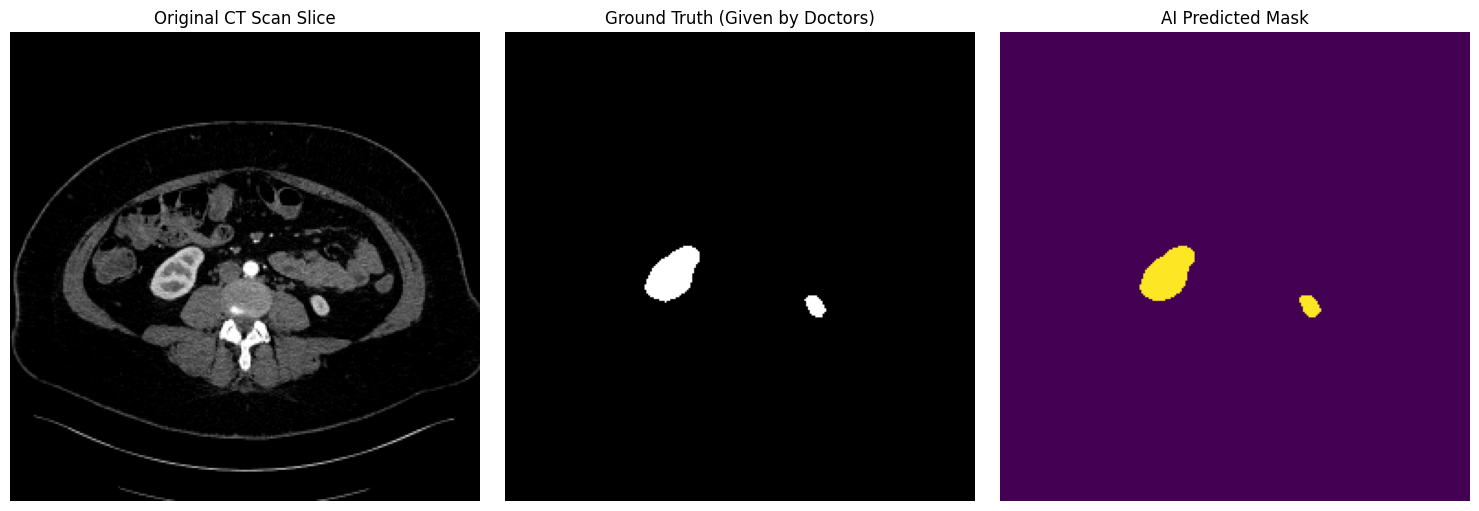

In [27]:
import random
import matplotlib.pyplot as plt

# Load the trained model back into memory
...

# Load the trained model back into memory
test_model = Attention_UNet_PlusPlus(in_channels=1, num_classes=1, deep_supervision=False).to(device)
test_model.load_state_dict(torch.load("attention_unet_plusplus_kits19.pth"))
test_model.eval()

# Pick a random image from your validation arrays
rand_idx = random.randint(0, len(val_slices)-1)
img_array = np.load(val_slices[rand_idx]["img_path"])
mask_array = np.load(val_slices[rand_idx]["mask_path"])

# Give it to the specific PyTorch format
tensor_img = torch.tensor(img_array).unsqueeze(0).unsqueeze(0).float().to(device)

with torch.no_grad():
    prediction = test_model(tensor_img)
    pred_mask = torch.sigmoid(prediction).squeeze().cpu().numpy()
    pred_mask = (pred_mask > 0.5).astype(np.uint8)

# Plot the beautiful side-by-side
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img_array, cmap='gray')
ax[0].set_title("Original CT Scan Slice")
ax[0].axis('off')

ax[1].imshow(mask_array, cmap='gray')
ax[1].set_title("Ground Truth (Given by Doctors)")
ax[1].axis('off')

ax[2].imshow(pred_mask, cmap='viridis')
ax[2].set_title("AI Predicted Mask")
ax[2].axis('off')

plt.tight_layout()
plt.show()
 

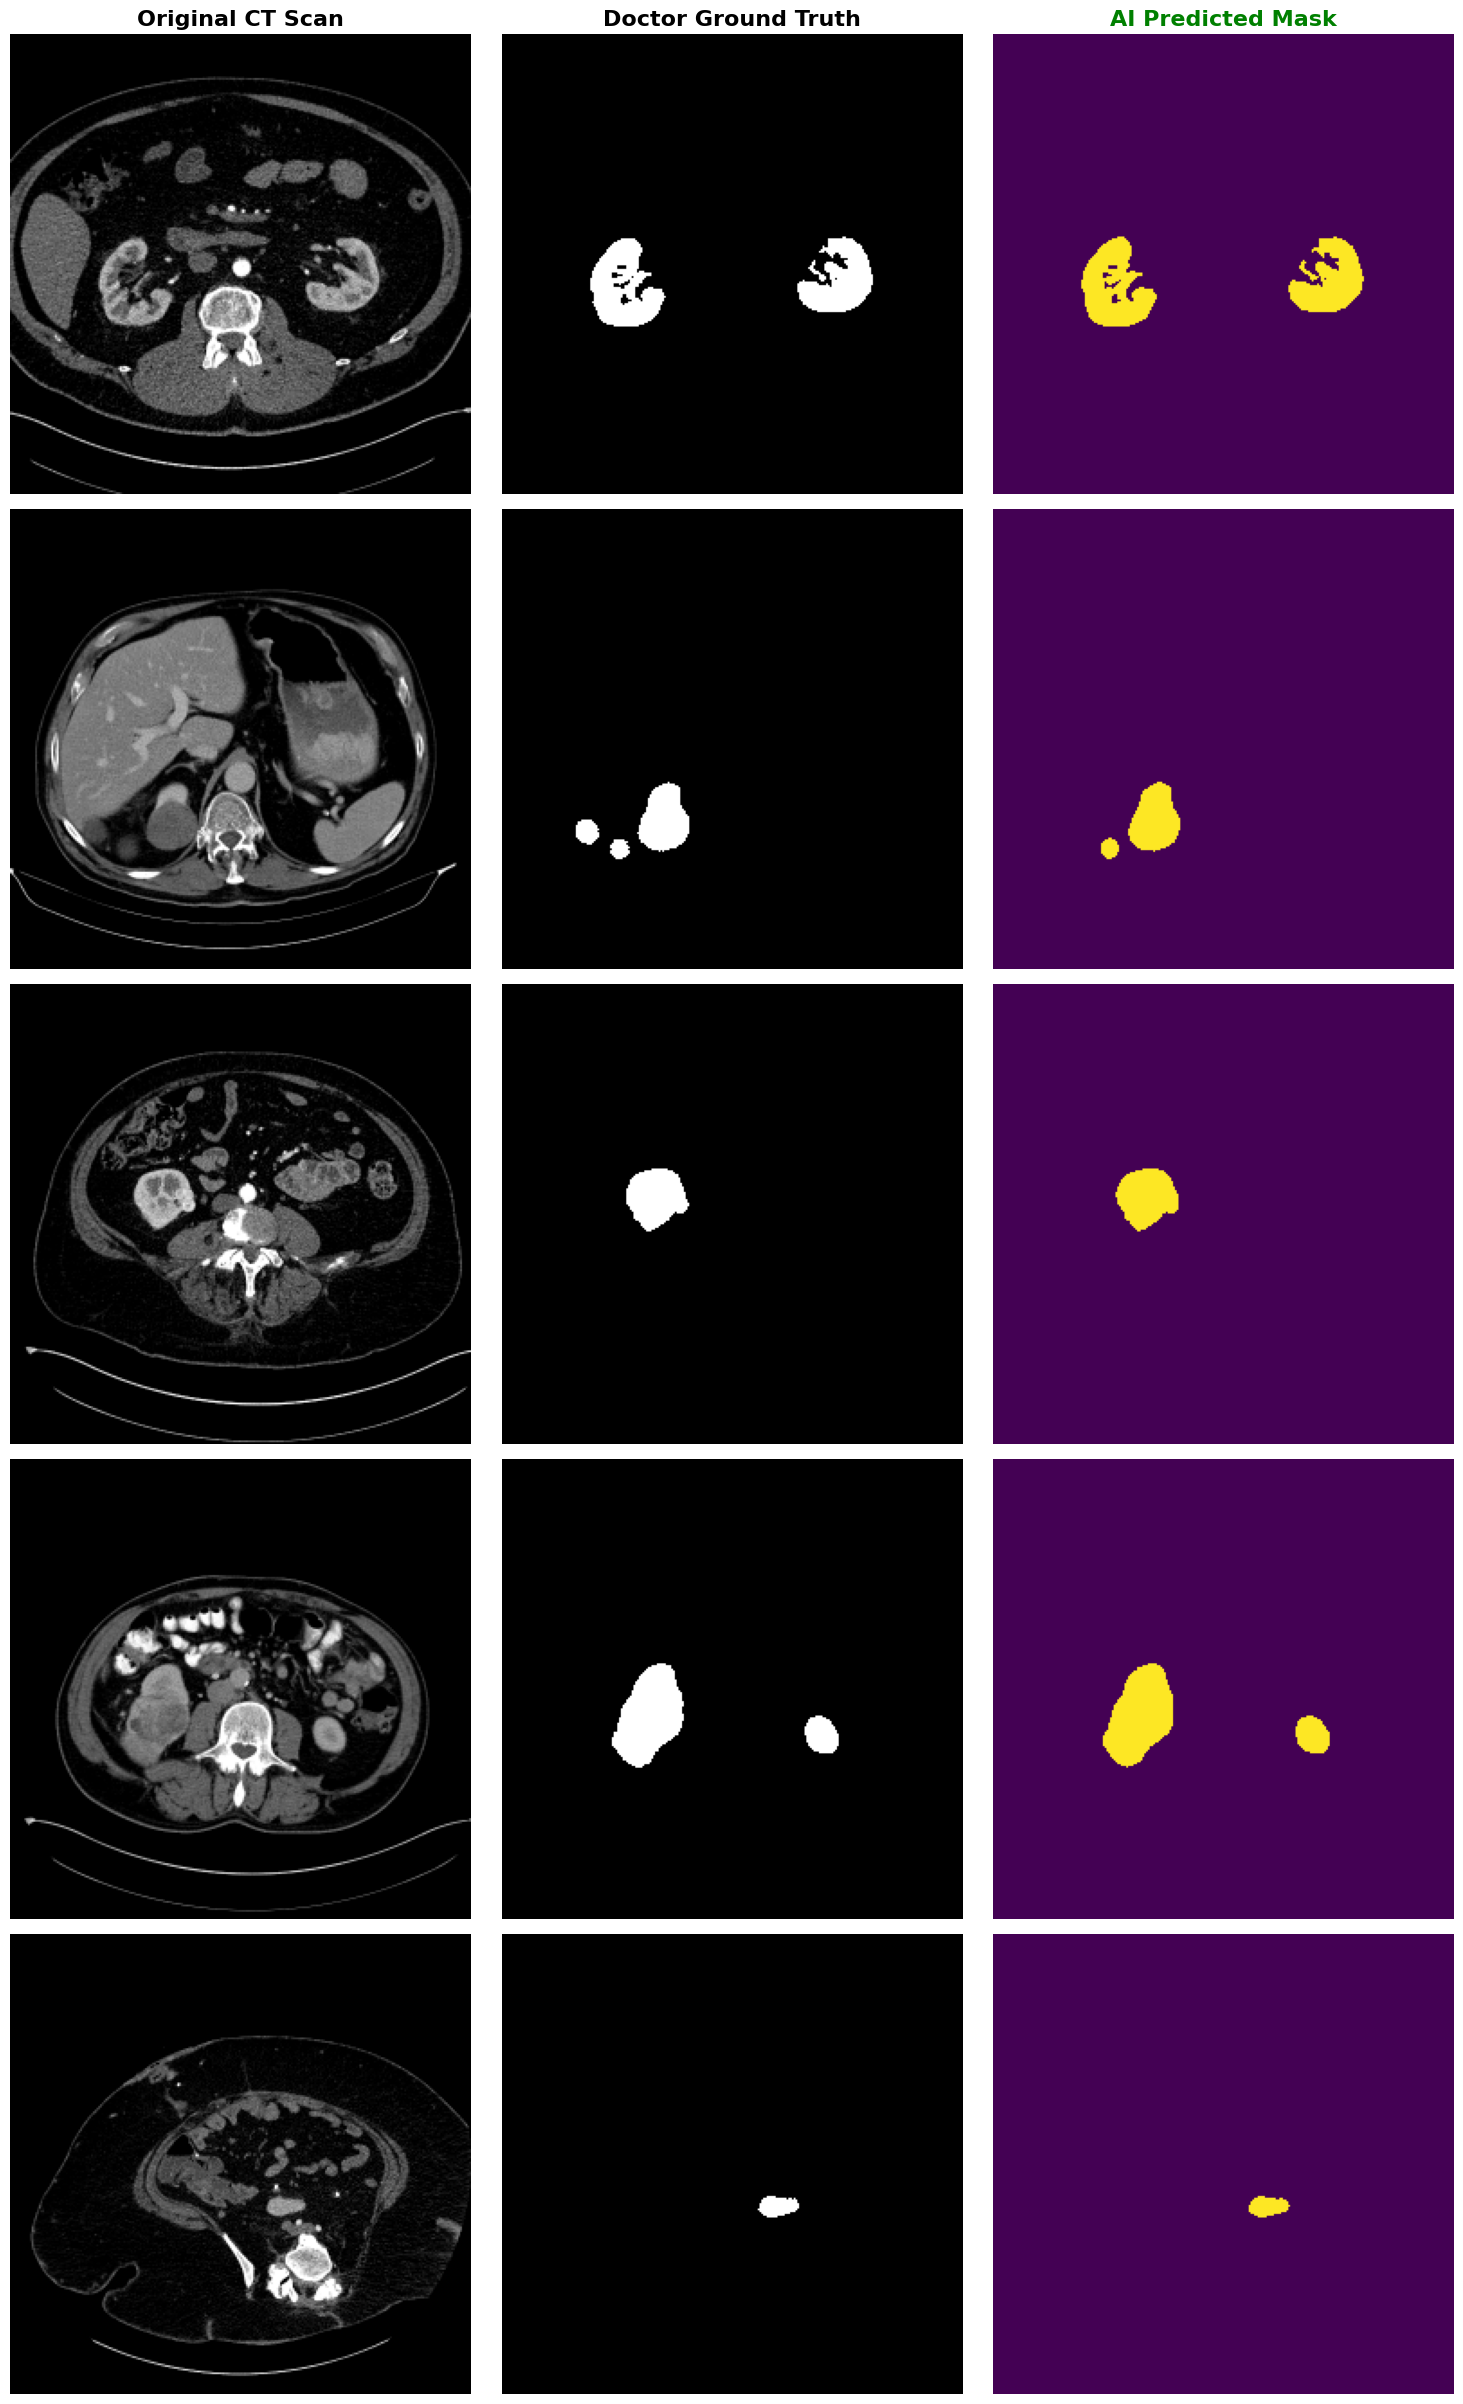

In [28]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

# Setting up a grid: 5 Rows (Scans) x 3 Columns (CT, True, AI)
NUM_SCANS = 5
fig, axes = plt.subplots(NUM_SCANS, 3, figsize=(15, 5 * NUM_SCANS))

for i in range(NUM_SCANS):
    # Grab a random pristine validation image
    rand_idx = random.randint(0, len(val_slices)-1)
    img_array = np.load(val_slices[rand_idx]["img_path"])
    mask_array = np.load(val_slices[rand_idx]["mask_path"])

    # Push to PyTorch format
    tensor_img = torch.tensor(img_array).unsqueeze(0).unsqueeze(0).float().to(device)

    # Predict
    with torch.no_grad():
        prediction = test_model(tensor_img)
        pred_mask = torch.sigmoid(prediction).squeeze().cpu().numpy()
        pred_mask = (pred_mask > 0.5).astype(np.uint8)

    # --- Plot Original CT Scan ---
    axes[i, 0].imshow(img_array, cmap='gray')
    if i == 0: axes[i, 0].set_title("Original CT Scan", fontsize=16, fontweight='bold')
    axes[i, 0].axis('off')

    # --- Plot Doctor's Ground Truth ---
    axes[i, 1].imshow(mask_array, cmap='gray')
    if i == 0: axes[i, 1].set_title("Doctor Ground Truth", fontsize=16, fontweight='bold')
    axes[i, 1].axis('off')

    # --- Plot Your AI Prediction ---
    axes[i, 2].imshow(pred_mask, cmap='viridis')
    if i == 0: axes[i, 2].set_title("AI Predicted Mask", fontsize=16, fontweight='bold', color='green')
    axes[i, 2].axis('off')

# Display everything beautifully aligned
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


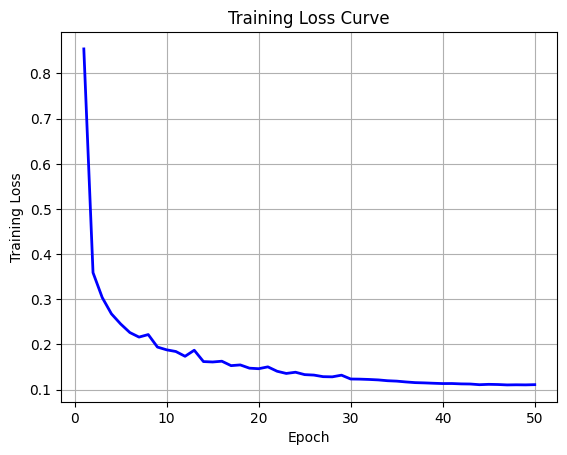

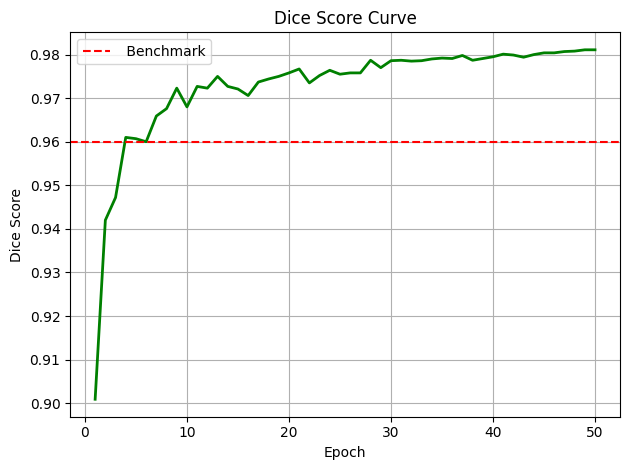

In [29]:
import matplotlib.pyplot as plt
import re

# 1. Paste your Kaggle console output here!
log_text = """

--- Epoch 1/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.8544 | Val Loss: 0.1308 | Val Dice: 0.9009
🌟 Saved new best model with Dice: 0.9009!

--- Epoch 2/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.3590 | Val Loss: 0.0750 | Val Dice: 0.9420
🌟 Saved new best model with Dice: 0.9420!

--- Epoch 3/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.3039 | Val Loss: 0.0661 | Val Dice: 0.9472
🌟 Saved new best model with Dice: 0.9472!

--- Epoch 4/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.2678 | Val Loss: 0.0486 | Val Dice: 0.9610
🌟 Saved new best model with Dice: 0.9610!

--- Epoch 5/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.2454 | Val Loss: 0.0498 | Val Dice: 0.9607

--- Epoch 6/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.2264 | Val Loss: 0.0494 | Val Dice: 0.9600

--- Epoch 7/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.2163 | Val Loss: 0.0420 | Val Dice: 0.9659
🌟 Saved new best model with Dice: 0.9659!

--- Epoch 8/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.2219 | Val Loss: 0.0398 | Val Dice: 0.9676
🌟 Saved new best model with Dice: 0.9676!

--- Epoch 9/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1942 | Val Loss: 0.0342 | Val Dice: 0.9723
🌟 Saved new best model with Dice: 0.9723!

--- Epoch 10/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1881 | Val Loss: 0.0392 | Val Dice: 0.9680

--- Epoch 11/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1844 | Val Loss: 0.0335 | Val Dice: 0.9727
🌟 Saved new best model with Dice: 0.9727!

--- Epoch 12/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1738 | Val Loss: 0.0340 | Val Dice: 0.9723

--- Epoch 13/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1872 | Val Loss: 0.0307 | Val Dice: 0.9750
🌟 Saved new best model with Dice: 0.9750!

--- Epoch 14/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1621 | Val Loss: 0.0334 | Val Dice: 0.9727

--- Epoch 15/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1612 | Val Loss: 0.0341 | Val Dice: 0.9721

--- Epoch 16/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1629 | Val Loss: 0.0360 | Val Dice: 0.9706

--- Epoch 17/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1531 | Val Loss: 0.0322 | Val Dice: 0.9737

--- Epoch 18/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1547 | Val Loss: 0.0312 | Val Dice: 0.9744

--- Epoch 19/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.48it/s]
Train Loss: 0.1475 | Val Loss: 0.0305 | Val Dice: 0.9750

--- Epoch 20/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1463 | Val Loss: 0.0297 | Val Dice: 0.9758
🌟 Saved new best model with Dice: 0.9758!

--- Epoch 21/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1504 | Val Loss: 0.0284 | Val Dice: 0.9767
🌟 Saved new best model with Dice: 0.9767!

--- Epoch 22/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.48it/s]
Train Loss: 0.1407 | Val Loss: 0.0322 | Val Dice: 0.9735

--- Epoch 23/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1358 | Val Loss: 0.0301 | Val Dice: 0.9752

--- Epoch 24/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.48it/s]
Train Loss: 0.1385 | Val Loss: 0.0287 | Val Dice: 0.9764

--- Epoch 25/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.48it/s]
Train Loss: 0.1332 | Val Loss: 0.0298 | Val Dice: 0.9755

--- Epoch 26/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.48it/s]
Train Loss: 0.1322 | Val Loss: 0.0294 | Val Dice: 0.9758

--- Epoch 27/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.48it/s]
Train Loss: 0.1287 | Val Loss: 0.0294 | Val Dice: 0.9758

--- Epoch 28/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1283 | Val Loss: 0.0260 | Val Dice: 0.9787
🌟 Saved new best model with Dice: 0.9787!

--- Epoch 29/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1320 | Val Loss: 0.0279 | Val Dice: 0.9770

--- Epoch 30/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1235 | Val Loss: 0.0261 | Val Dice: 0.9786

--- Epoch 31/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1232 | Val Loss: 0.0259 | Val Dice: 0.9787
🌟 Saved new best model with Dice: 0.9787!

--- Epoch 32/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1225 | Val Loss: 0.0263 | Val Dice: 0.9785

--- Epoch 33/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.48it/s]
Train Loss: 0.1215 | Val Loss: 0.0261 | Val Dice: 0.9786

--- Epoch 34/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1197 | Val Loss: 0.0256 | Val Dice: 0.9790
🌟 Saved new best model with Dice: 0.9790!

--- Epoch 35/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1188 | Val Loss: 0.0253 | Val Dice: 0.9792
🌟 Saved new best model with Dice: 0.9792!

--- Epoch 36/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1170 | Val Loss: 0.0255 | Val Dice: 0.9791

--- Epoch 37/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1155 | Val Loss: 0.0247 | Val Dice: 0.9798
🌟 Saved new best model with Dice: 0.9798!

--- Epoch 38/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1149 | Val Loss: 0.0259 | Val Dice: 0.9787

--- Epoch 39/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1141 | Val Loss: 0.0254 | Val Dice: 0.9791

--- Epoch 40/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1134 | Val Loss: 0.0249 | Val Dice: 0.9795

--- Epoch 41/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1135 | Val Loss: 0.0243 | Val Dice: 0.9801
🌟 Saved new best model with Dice: 0.9801!

--- Epoch 42/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.48it/s]
Train Loss: 0.1127 | Val Loss: 0.0246 | Val Dice: 0.9799

--- Epoch 43/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1124 | Val Loss: 0.0251 | Val Dice: 0.9794

--- Epoch 44/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1109 | Val Loss: 0.0244 | Val Dice: 0.9800

--- Epoch 45/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1117 | Val Loss: 0.0239 | Val Dice: 0.9804
🌟 Saved new best model with Dice: 0.9804!

--- Epoch 46/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1113 | Val Loss: 0.0239 | Val Dice: 0.9804

--- Epoch 47/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1104 | Val Loss: 0.0236 | Val Dice: 0.9807
🌟 Saved new best model with Dice: 0.9807!

--- Epoch 48/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1107 | Val Loss: 0.0235 | Val Dice: 0.9808
🌟 Saved new best model with Dice: 0.9808!

--- Epoch 49/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1105 | Val Loss: 0.0232 | Val Dice: 0.9811
🌟 Saved new best model with Dice: 0.9811!

--- Epoch 50/50 ---
Training: 100%|██████████| 777/777 [08:23<00:00,  1.54it/s]
Validating: 100%|██████████| 195/195 [00:35<00:00,  5.49it/s]
Train Loss: 0.1110 | Val Loss: 0.0231 | Val Dice: 0.9811
🌟 Saved new best model with Dice: 0.9811!



""" # <--- Put all your epochs here

# 2. Automatically generate the lists you need for your code
train_losses = [float(x) for x in re.findall(r"Train Loss: ([0-9.]+)", log_text)]
dice_curve_fixed = [float(x) for x in re.findall(r"Val Dice: ([0-9.]+)", log_text)]


# 3. Your High-Resolution Loss Curve Plot
plt.figure()
plt.plot(range(1, len(train_losses) + 1), train_losses, color='blue', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.savefig("loss_curve.png", dpi=300)
plt.show()

# 4. Your High-Resolution Dice Score Plot
plt.figure()
plt.plot(range(1, len(dice_curve_fixed) + 1), dice_curve_fixed, color='green', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice Score Curve")
plt.axhline(y=0.96, color='red', linestyle='--', label=' Benchmark')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("dice_curve.png", dpi=300)
plt.show()
